# Modelo geral — previsão diária do total de `qt_material`

**Objetivo:** responder se compensa prever **direto o total do dia** (uma série só, sem canal e sem categoria) em vez de prever cada canal × categoria e somar, como no `modelo_machine_learning.ipynb`.

**Mesmas regras do modelo por categoria**
- Mesma base corrigida (`42_sql_base_modelagem.sql`), somada no total do dia.
- Mesmas features de calendário: dia da semana, dia do mês, uma coluna por data comemorativa (semana anterior + dia), `black_november` e `campanha`.
- Mesma validação faseada (14 dias à frente, 7 rodadas de 01/04 a 30/06), mesmos baselines, mesmas duas etapas (parâmetros padrão → ajuste do vencedor rodada a rodada) e mesmo quality gate.

**O que muda**
- **Desconto:** sem categoria, a premissa é a **taxa média de desconto da semana do total** (`taxa_desconto_semana`).
- **Sem canal e categoria:** o modelo não tem `is_app` nem dummies de categoria, então entrega só o total. Para ter canal e categoria, seria preciso repartir o total por proporções.
- **Lags:** como a série é uma só e curta (242 dias), testamos explicitamente se o histórico (lags de 14 a 28 dias) ajuda cada modelo.

**Roteiro:** 1. Base · 2. Features · 3. Validação · 4. Baselines · 5. Etapa 1 · 6. Os lags ajudam? · 7. Comparação da etapa 1 · 8. Etapa 2 · 9. Resultado final · 10. SHAP · 11. Sensibilidade ao desconto · 12. Geral × categoria · 13. Conclusões

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gb_ml.io import estimate_query_bytes, read_query

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_ID = "gms-prod-01"
BQ_LOCATION = "us-east4"
TABLE_ID = "gms-prod-01.projeto_gb.fact_vendas"
STG_TABLE_ID = "gms-prod-01.projeto_gb.stg_fact_vendas"

START_DATE = "2025-11-01"
END_DATE = "2026-06-30"

DATE_FILTER = f"DATE(dt_hr_venda) BETWEEN DATE '{START_DATE}' AND DATE '{END_DATE}'"

# Validação faseada: o teste começa depois de 5 meses de treino
INICIO_TESTE = "2026-04-01"

COR_REAL = "#333333"
CORES_MODELO = {
    "naive_sazonal": "#9e9e9e",
    "mm7": "#bdbdbd",
    "mm28": "#757575",
    "regressao_linear": "#1f4e79",
    "lightgbm": "#6a994e",
    "xgboost": "#d17a22",
    "vencedor_ajustado": "#a23b72",
    "categoria (diário)": "#6a994e",
    "geral (diário)": "#1f4e79",
    "horário": "#a23b72",
}

## Consumo BigQuery

Antes de cada consulta, fazemos um **dry-run** para estimar bytes processados. As consultas ficam na pasta `sql/`, numeradas na ordem de uso no projeto.

In [2]:
from pathlib import Path


def run_bq(sql: str, label: str | None = None) -> pd.DataFrame:
    bytes_processed = estimate_query_bytes(sql, project_id=PROJECT_ID, location=BQ_LOCATION)
    mb = bytes_processed / 1024**2
    print(f"[BigQuery] {label or 'query'} | estimativa processada: {mb:,.2f} MB")
    return read_query(sql, project_id=PROJECT_ID, location=BQ_LOCATION)


PASTA_SQL = next(
    pasta / "sql" for pasta in [Path.cwd(), *Path.cwd().parents] if (pasta / "sql").is_dir()
)


def carregar_sql(arquivo: str, **parametros) -> str:
    """Lê sql/<arquivo> e preenche os parâmetros {TABLE_ID}, {DATE_FILTER} etc."""
    modelo = (PASTA_SQL / arquivo).read_text(encoding="utf-8")
    return modelo.format(
        TABLE_ID=TABLE_ID,
        STG_TABLE_ID=STG_TABLE_ID,
        DATE_FILTER=DATE_FILTER,
        START_DATE=START_DATE,
        END_DATE=END_DATE,
        **parametros,
    )

# 1. Base de modelagem

Usamos a mesma query do modelo por categoria (`42_sql_base_modelagem.sql`, com `ABS` na receita, `ROUND` nos valores, categoria recuperada e grade completa) e somamos tudo no total do dia com `base_geral`. A taxa de desconto passa a ser a do total da semana.

In [3]:
from gb_ml.features import base_geral

sql_base_modelagem = carregar_sql("42_sql_base_modelagem.sql")
base_categoria = run_bq(sql_base_modelagem, "base de modelagem: dia x canal x categoria")
base_categoria["data"] = pd.to_datetime(base_categoria["data"])
base_categoria["qt_material"] = base_categoria["qt_material"].astype(float)

base = base_geral(base_categoria)
print(f"{len(base):,} linhas (uma por dia) | {base['data'].min():%d/%m/%Y} a {base['data'].max():%d/%m/%Y}")
display(base.head())

[BigQuery] base de modelagem: dia x canal x categoria | estimativa processada: 5.87 MB


242 linhas (uma por dia) | 01/11/2025 a 30/06/2026


,data,qt_material,receita_aprovada,vlr_venda_desconto,taxa_desconto_semana,des_canal_venda_final_agrup,des_categoria_material
0,2025-11-01,"27,265.0000","1,856,093.3100","1,068,230.0800",0.3979,TOTAL,TOTAL
1,2025-11-02,"36,328.0000","2,266,422.2900","1,656,038.4300",0.3979,TOTAL,TOTAL
2,2025-11-03,"148,539.0000","6,681,187.5200","8,539,908.1600",0.5402,TOTAL,TOTAL
3,2025-11-04,"125,065.0000","5,213,371.5200","6,447,197.4600",0.5402,TOTAL,TOTAL
4,2025-11-05,"151,324.0000","5,724,281.4800","7,142,309.1400",0.5402,TOTAL,TOTAL


### Conferência da base

O total da base geral precisa bater com a tabela original.

In [4]:
BASE_CONFERIDA = base

sql_conferencia_modelagem = carregar_sql("43_sql_conferencia_modelagem.sql")
original = run_bq(sql_conferencia_modelagem, "totais da tabela original").iloc[0]

conferencia = pd.DataFrame({
    "tabela original": original[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].astype(float),
    "base de modelagem": BASE_CONFERIDA[["qt_material", "receita_aprovada", "vlr_venda_desconto"]].sum(),
})
conferencia["diferença"] = conferencia["base de modelagem"] - conferencia["tabela original"]
display(conferencia)
assert abs(conferencia.loc["qt_material", "diferença"]) < 1e-6, "a base perdeu ou duplicou volume"

[BigQuery] totais da tabela original | estimativa processada: 5.41 MB


,tabela original,base de modelagem,diferença
qt_material,"9,896,201.0000","9,896,201.0000",0.0000
receita_aprovada,"532,413,485.7000","532,413,485.7000",0.0000
vlr_venda_desconto,"379,767,342.7800","379,767,342.7800",0.0000


# 2. Features

| Feature | Tipo | Por quê |
|---|---|---|
| `dia_semana` | 0 = segunda ... 6 = domingo (dummies na regressão linear) | padrão semanal |
| `dia_mes` | 1 a 31 (só nas árvores) | possível efeito de início/fim de mês |
| `evento_*` | uma coluna por data comemorativa: 1 na semana anterior e no dia | a alta começa antes da data |
| `black_november` | 1 da primeira segunda-feira de novembro ao domingo após a Black Friday | o mês inteiro fica 3 a 4× acima do normal |
| `campanha` | 1 nas campanhas pontuais informadas pelo negócio | campanha de maio |
| `taxa_desconto_semana` | taxa média de desconto do total na semana | premissa: informada pelo time de desconto |
| `lag_14`, `lag_21`, `lag_28`, `mm7_lag14`, `mm28_lag14` | histórico do total (testado na seção 6 e na etapa 2) | nível recente; todos com pelo menos 14 dias de atraso |

**Mês e ano não são usados**, pelo mesmo motivo do modelo por categoria: com 8 meses de base, cada mês aparece uma vez e o modelo decoraria o mês. Devem entrar quando houver 2 anos de dados.

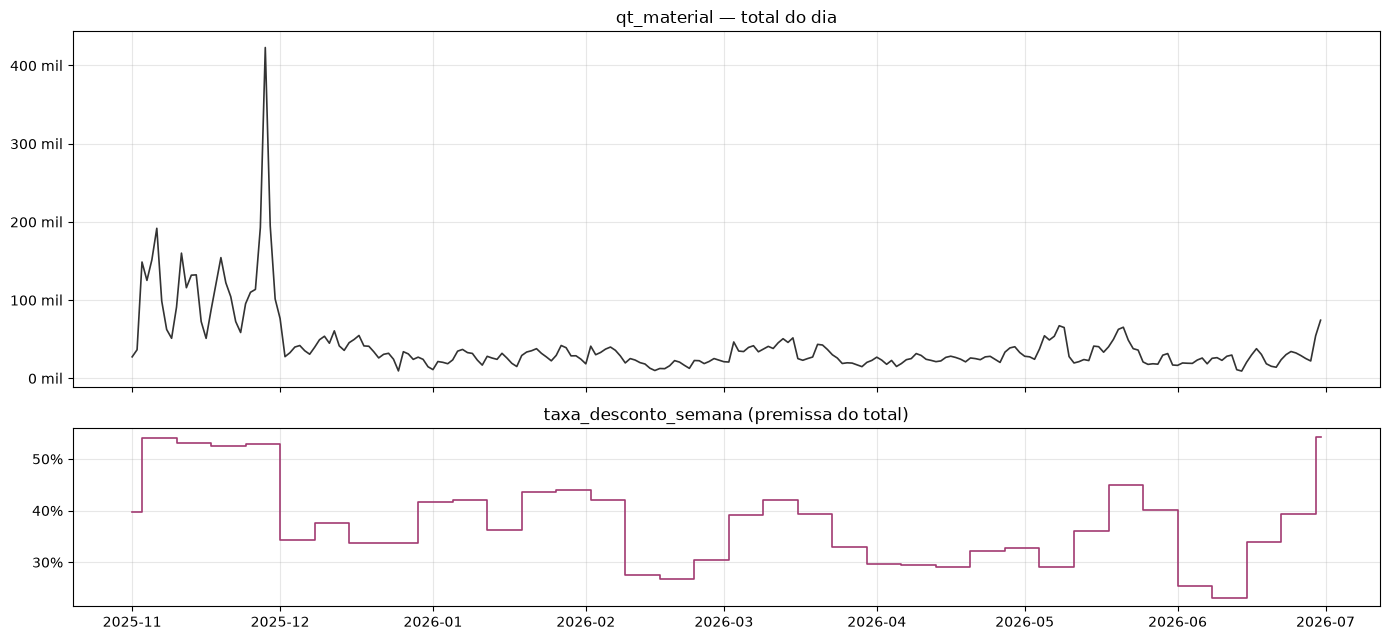

In [5]:
from gb_ml.features import COLUNA_DESCONTO_GERAL, montar_features

df = montar_features(base)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1.5]})
ax1.plot(df["data"], df["qt_material"], color=COR_REAL, lw=1.2)
ax1.set_title("qt_material — total do dia")
ax1.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
ax1.grid(alpha=0.3)
ax2.step(df["data"], df[COLUNA_DESCONTO_GERAL], where="post", color="#a23b72", lw=1.2)
ax2.set_title("taxa_desconto_semana (premissa do total)")
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Validação faseada

Mesma regra do notebook por categoria: em cada rodada o modelo treina com **tudo que aconteceu até a véspera**, prevê os **próximos 14 dias** e só depois recebe esses 14 dias para a rodada seguinte (janela expansível). São 7 rodadas, de 01/04 a 30/06, com cerca de 5 meses de treino na primeira.

**Escolha do modelo em duas etapas**
1. **Etapa 1 — parâmetros padrão:** os três modelos (regressão linear, LightGBM, XGBoost) com os parâmetros padrão das bibliotecas.
2. **Etapa 2 — ajuste do vencedor:** antes de cada rodada, o vencedor testa uma grade de parâmetros nas 3 janelas de 14 dias anteriores (só dados até a véspera) e usa a melhor combinação. Se o ajuste não reduzir o erro, o modelo final fica com os parâmetros padrão.

**Métricas:** WAPE (Σ|erro| ÷ Σ real), MAE, viés (positivo = superestima) e skill contra o melhor baseline. **Quality gate:** skill > 0 e |viés| < 10% no total do dia.

In [6]:
from gb_ml.model import (
    backtest_com_ajuste, baseline, buscar_parametros, dias_ineditos, erro_por_rodada,
    folds_de_ajuste, gerar_folds, metricas, metricas_complementares, resumo_backtest, rodar_backtest,
)

folds_teste = gerar_folds(INICIO_TESTE, END_DATE)
display(folds_teste.assign(dias_de_treino=(folds_teste["inicio"] - pd.Timestamp(START_DATE)).dt.days))


def plot_real_previsto(modelos: list[str], titulo: str, fonte: dict | None = None) -> None:
    """Total do dia: real × previsto por modelo, com as divisões das rodadas."""
    fonte = previsoes if fonte is None else fonte
    fig, ax = plt.subplots(figsize=(14, 4.5))
    real = fonte[modelos[0]].groupby("data")["qt_material"].sum()
    ax.plot(real.index, real, color=COR_REAL, lw=2, label="real")
    for modelo in modelos:
        previsto = fonte[modelo].groupby("data")["previsto"].sum()
        ax.plot(previsto.index, previsto, color=CORES_MODELO.get(modelo, "#7d5ba6"), lw=1.5, label=modelo)
    for inicio in folds_teste["inicio"]:
        ax.axvline(inicio, color="#999999", ls=":", lw=1)
    ax.set_title(titulo)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:,.0f} mil")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def tabela_comparacao(modelos: list[str], fonte: dict | None = None) -> pd.DataFrame:
    fonte = previsoes if fonte is None else fonte
    tabela = pd.DataFrame({m: resumo_backtest(fonte[m]) for m in modelos}).T
    tabela["skill_vs_baseline"] = 1 - tabela["wape_dia"] / WAPE_BASELINE
    tabela["passa_no_gate"] = (tabela["skill_vs_baseline"] > 0) & (tabela["vies_dia"].abs() < 0.10)
    return tabela.sort_values("wape_dia")


def plot_erro_rodada(modelos: list[str], titulo: str, fonte: dict | None = None) -> pd.DataFrame:
    fonte = previsoes if fonte is None else fonte
    fig, ax = plt.subplots(figsize=(14, 4))
    for modelo in modelos:
        rodadas = erro_por_rodada(fonte[modelo])
        ax.plot(rodadas["rodada"], rodadas["wape"], marker="o", color=CORES_MODELO.get(modelo, "#7d5ba6"), label=modelo)
    rotulos = [f"{r}\n{i:%d/%m}–{f:%d/%m}" for r, i, f in folds_teste[["rodada", "inicio", "fim"]].itertuples(index=False)]
    ax.set_xticks(folds_teste["rodada"], rotulos)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({m: erro_por_rodada(fonte[m]).set_index("rodada")["wape"] for m in modelos})


def formatar_pct(tabela: pd.DataFrame) -> pd.DataFrame:
    return tabela.map(lambda v: ("—" if pd.isna(v) else f"{v:.1%}") if isinstance(v, float) else v)

,rodada,inicio,fim,dias_de_treino
0,1,2026-04-01,2026-04-14,151
1,2,2026-04-15,2026-04-28,165
2,3,2026-04-29,2026-05-12,179
3,4,2026-05-13,2026-05-26,193
4,5,2026-05-27,2026-06-09,207
5,6,2026-06-10,2026-06-23,221
6,7,2026-06-24,2026-06-30,235


# 4. Baselines

Mesmos baselines do modelo por categoria, agora calculados direto no total: **naive_sazonal** (repete a última semana), **mm7** e **mm28** (médias móveis de 7 e 28 dias).

In [7]:
previsoes = {}
for metodo in ["naive_sazonal", "mm7", "mm28"]:
    previsoes[metodo] = rodar_backtest(df, folds_teste, baseline(metodo))

resumo_baselines = pd.DataFrame({m: resumo_backtest(p) for m, p in previsoes.items()}).T
display(resumo_baselines)
MELHOR_BASELINE = resumo_baselines["wape_dia"].idxmin()
WAPE_BASELINE = resumo_baselines.loc[MELHOR_BASELINE, "wape_dia"]
print(f"Melhor baseline (WAPE do total do dia): {MELHOR_BASELINE}")

,wape_serie,wape_dia,mae_dia,vies_dia
naive_sazonal,0.4113,0.4113,"12,107.6593",-0.0027
mm7,0.3576,0.3576,"10,525.9011",-0.0027
mm28,0.3868,0.3868,"11,384.5137",0.0169


Melhor baseline (WAPE do total do dia): mm7


# 5. Etapa 1 — os três modelos com parâmetros padrão

| Modelo | Configuração padrão |
|---|---|
| **Regressão linear** | mínimos quadrados, alvo em `log(1 + qt_material)`, sem lags, erros-padrão robustos (HC1) |
| **LightGBM** | parâmetros padrão da biblioteca, objetivo Poisson, sem lags |
| **XGBoost** | parâmetros padrão da biblioteca, objetivo Poisson, sem lags |

Mesma configuração da etapa 1 do modelo por categoria. Atenção: com uma série só, o treino tem **uma linha por dia** (151 dias na primeira rodada), contra 18 linhas por dia no modelo por categoria.

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
regressao_linear,0.2610,0.2610,"7,682.2650",-0.1200,0.2702,False
lightgbm,0.4067,0.4067,"11,971.1577",0.0321,-0.1373,False
xgboost,0.5073,0.5073,"14,931.5178",0.0545,-0.4186,False


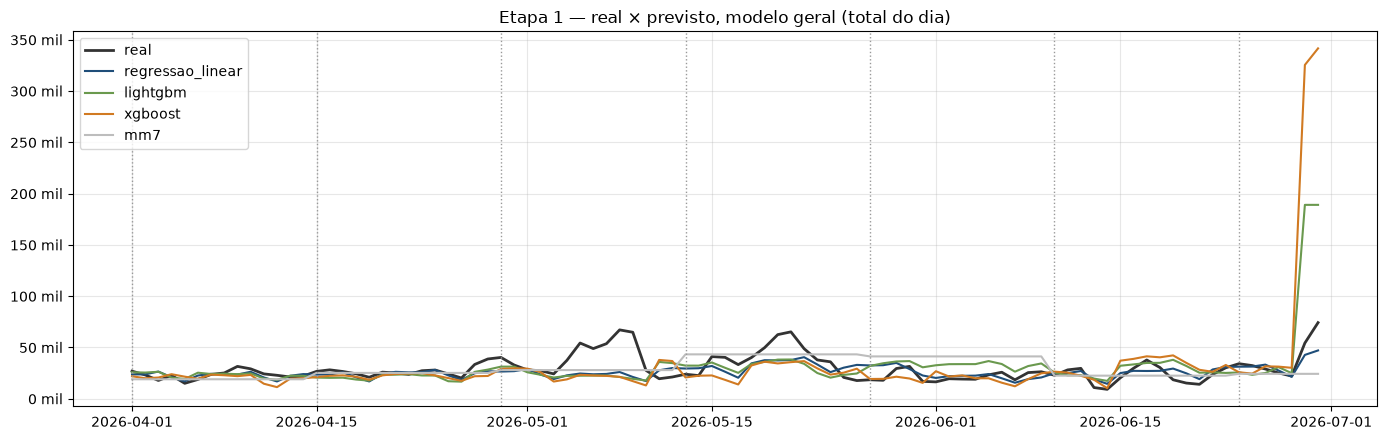

In [8]:
from gb_ml.model import ajustar_linear, lightgbm, linear, xgboost

FABRICAS = {"regressao_linear": linear, "lightgbm": lightgbm, "xgboost": xgboost}
PADRAO = {
    "regressao_linear": {"alvo": "log", "usar_lags": False},
    "lightgbm": {"alvo": "poisson", "usar_lags": False},
    "xgboost": {"alvo": "poisson", "usar_lags": False},
}
for nome, fabrica in FABRICAS.items():
    previsoes[nome] = rodar_backtest(df, folds_teste, fabrica(**PADRAO[nome]))

display(tabela_comparacao(list(FABRICAS)))
plot_real_previsto([*FABRICAS, MELHOR_BASELINE], "Etapa 1 — real × previsto, modelo geral (total do dia)")

### Resultados estatísticos da regressão

Regressão ajustada com toda a base. **Efeito %** = e^coeficiente − 1; para o desconto, o efeito é de **+10 pontos percentuais**.

In [9]:
modelo_linear = ajustar_linear(df, **PADRAO["regressao_linear"])
print(f"R² = {modelo_linear.rsquared:.3f} | R² ajustado = {modelo_linear.rsquared_adj:.3f} | n = {int(modelo_linear.nobs)}")
ic = modelo_linear.conf_int()
escala = pd.Series(1.0, index=modelo_linear.params.index)
escala[COLUNA_DESCONTO_GERAL] = 0.10
coeficientes = pd.DataFrame({
    "efeito_%": np.expm1(modelo_linear.params * escala),
    "ic95_inf": np.expm1(ic[0] * escala),
    "ic95_sup": np.expm1(ic[1] * escala),
    "p_valor": modelo_linear.pvalues,
}).drop(index="const")
coeficientes["significativo_5%"] = coeficientes["p_valor"] < 0.05
display(coeficientes)

R² = 0.750 | R² ajustado = 0.734 | n = 242


,efeito_%,ic95_inf,ic95_sup,p_valor,significativo_5%
taxa_desconto_semana,0.3415,0.2514,0.4380,0.0000,True
evento_ano_novo,-0.3071,-0.5406,0.0453,0.0803,False
evento_dia_consumidor,0.4057,0.1976,0.6499,0.0000,True
evento_dia_maes,1.1069,0.7390,1.5527,0.0000,True
evento_dia_namorados,0.3058,0.1597,0.4703,0.0000,True
evento_black_friday,0.0799,-0.2582,0.5721,0.6884,False
evento_natal,0.1450,-0.1034,0.4623,0.2779,False
black_november,1.5192,1.0741,2.0597,0.0000,True
campanha,0.4198,0.2623,0.5968,0.0000,True
dia_semana_1,0.1088,-0.0319,0.2699,0.1358,False


### Esboço das árvores

Árvore substituta de 3 níveis que imita cada modelo de árvore treinado com toda a base (mesma ideia do notebook por categoria). Os valores nas folhas estão em `qt_material` do total do dia.

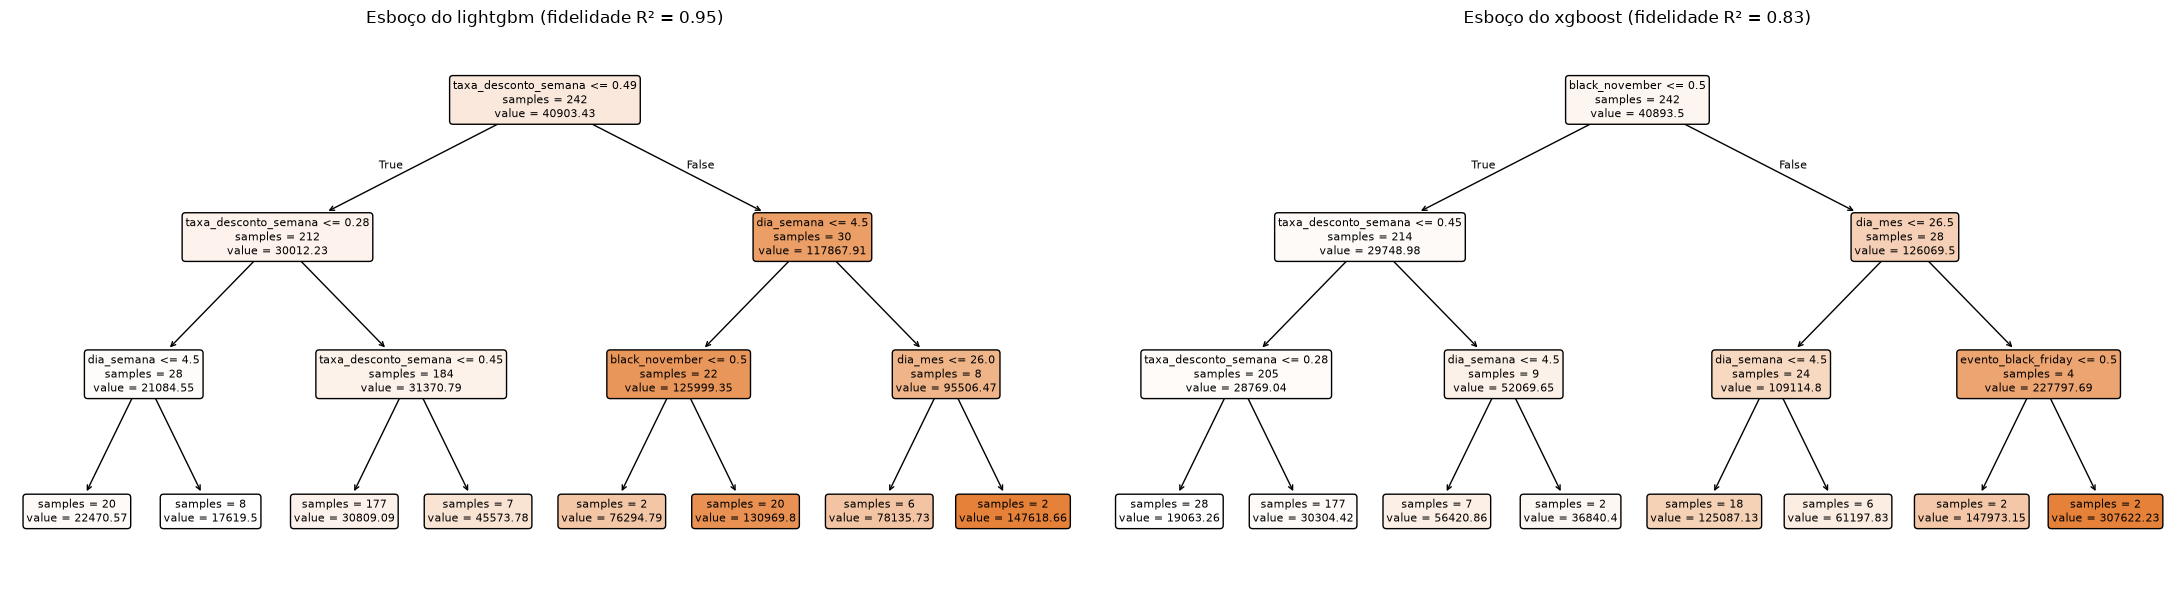

In [10]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

from gb_ml.features import matriz_arvore
from gb_ml.model import criar_lightgbm, criar_xgboost

CRIAR = {"lightgbm": criar_lightgbm, "xgboost": criar_xgboost}


def treinar_arvore(nome: str, parametros: dict):
    extras = {k: v for k, v in parametros.items() if k not in ("alvo", "usar_lags")}
    X = matriz_arvore(df, parametros["usar_lags"])
    y = np.log1p(df["qt_material"]) if parametros["alvo"] == "log" else df["qt_material"]
    modelo = CRIAR[nome](parametros["alvo"], **extras).fit(X, y)
    previsto = modelo.predict(X)
    return modelo, X, np.expm1(previsto) if parametros["alvo"] == "log" else previsto


fig, eixos = plt.subplots(1, 2, figsize=(22, 6))
for ax, nome in zip(eixos, ["lightgbm", "xgboost"]):
    _, X, previsto = treinar_arvore(nome, PADRAO[nome])
    X = X.fillna(-1).loc[:, lambda d: d.std() > 0]
    esboco = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X, previsto)
    plot_tree(esboco, feature_names=list(X.columns), filled=True, rounded=True, impurity=False,
              precision=2, fontsize=8, ax=ax)
    ax.set_title(f"Esboço do {nome} (fidelidade R² = {esboco.score(X, previsto):.2f})")
plt.tight_layout()
plt.show()

### Diagnóstico

- **A regressão linear vence com folga:** WAPE do total do dia de **26,1%** (skill de 27% sobre o mm7), contra 40,7% do LightGBM e 50,7% do XGBoost, que ficam **piores que o baseline**.
- **Por que as árvores falham no total:**
  - **Poucos dados:** a primeira rodada treina com só 151 linhas (uma por dia), pouco para aprender interações.
  - **Não extrapolam:** na última rodada (24 a 30/06), a taxa de desconto da semana subiu para o nível da Black November. As árvores "pularam" para a folha da Black November e previram 190 a 340 mil por dia, contra um real de 55 a 74 mil. O erro dessa rodada passou de 100%.
  - A regressão, em log, trata o desconto como um efeito proporcional e não tem esse salto.
- **Esboço das árvores:** o LightGBM decide primeiro pela taxa de desconto da semana (acima de 49%) e o XGBoost pela Black November. Os dois usam o desconto como atalho para identificar novembro.
- **Efeitos da regressão (R² = 0,75, n = 242 dias):**
  - **desconto:** +10 p.p. → **+34%** de volume;
  - **Black November:** **+152%**; **campanha:** +42%;
  - **Dia das Mães:** +111%; **Dia do Consumidor:** +41%; **Dia dos Namorados:** +31%;
  - **domingo:** −25%.
  - Natal, semana da Black Friday e Ano Novo não são significativos a 5%. São os mesmos sinais do modelo por categoria.

# 6. Os lags ajudam?

Cada modelo roda de novo com os mesmos parâmetros padrão, agora **com** os lags do total (`lag_14`, `lag_21`, `lag_28`, `mm7_lag14`, `mm28_lag14`). Na regressão linear, os lags entram em log, e os primeiros 41 dias (sem histórico suficiente, ou seja, quase toda a Black November) ficam fora do ajuste.

In [11]:
lags = []
for nome, fabrica in FABRICAS.items():
    com_lags = rodar_backtest(df, folds_teste, fabrica(**{**PADRAO[nome], "usar_lags": True}))
    previsoes[f"{nome} + lags"] = com_lags
    for rotulo, chave in [("sem lags", nome), ("com lags", f"{nome} + lags")]:
        lags.append({"modelo": nome, "versão": rotulo, **resumo_backtest(previsoes[chave])})
lags = pd.DataFrame(lags).pivot(index="modelo", columns="versão", values=["wape_dia", "vies_dia"])
display(formatar_pct(lags))

wape_dia          vies_dia         
versão           com lags sem lags com lags sem lags
modelo                                              
lightgbm            27.4%    40.7%    -8.6%     3.2%
regressao_linear    30.4%    26.1%   -18.0%   -12.0%
xgboost             37.3%    50.7%   -10.7%     5.5%

### Diagnóstico

- **Nas árvores, os lags ajudam muito:** o LightGBM cai de 40,7% para **27,4%** e o XGBoost de 50,7% para 37,3%. O histórico recente dá às árvores o nível da série e evita o salto da última rodada.
- **Na regressão linear, os lags pioram** (de 26,1% para 30,4%, com viés de −18%). Para usar lags, os primeiros 41 dias saem do ajuste, o que tira quase toda a Black November, e a regressão perde a referência de dias com desconto alto.
- **Mesmo com lags, nenhuma árvore passa a regressão sem lags** (27,4% contra 26,1%).

# 7. Comparação da etapa 1

O vencedor é o de menor WAPE do total do dia na etapa 1 (parâmetros padrão, sem lags). Os lags voltam como parâmetro na etapa 2.

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
regressao_linear,0.2610,0.2610,"7,682.2650",-0.1200,0.2702,False
mm7,0.3576,0.3576,"10,525.9011",-0.0027,0.0000,False
mm28,0.3868,0.3868,"11,384.5137",0.0169,-0.0816,False
lightgbm,0.4067,0.4067,"11,971.1577",0.0321,-0.1373,False
naive_sazonal,0.4113,0.4113,"12,107.6593",-0.0027,-0.1503,False
xgboost,0.5073,0.5073,"14,931.5178",0.0545,-0.4186,False


Vencedor da etapa 1: regressao_linear


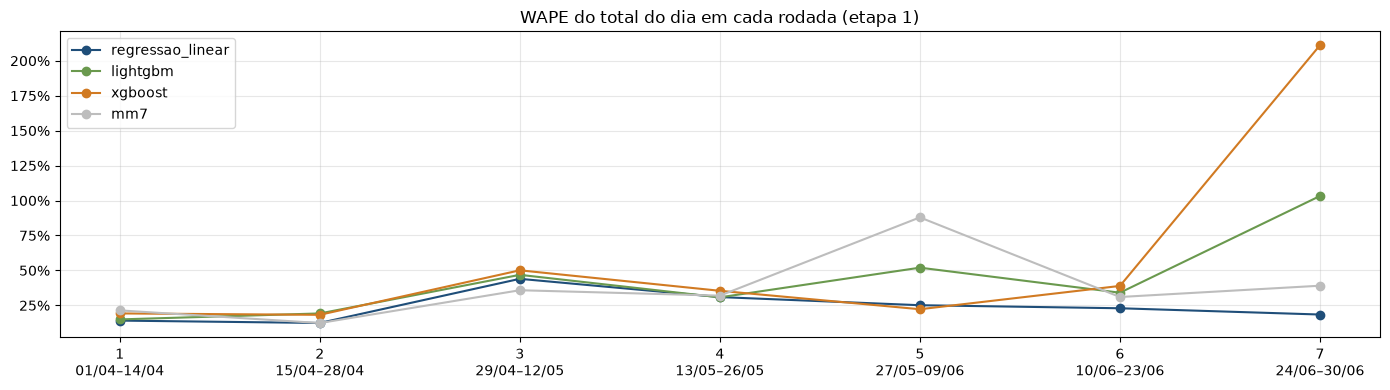

,regressao_linear,lightgbm,xgboost,mm7
rodada,,,,
1,0.1410,0.1495,0.1922,0.2141
2,0.1240,0.1922,0.1823,0.1235
3,0.4398,0.4684,0.5008,0.3582
4,0.3093,0.3073,0.3542,0.3196
5,0.2510,0.5197,0.2223,0.8794
6,0.2293,0.3406,0.3890,0.3098
7,0.1844,1.0324,2.1110,0.3906


In [12]:
etapa_1 = tabela_comparacao([*FABRICAS, "naive_sazonal", "mm7", "mm28"])
display(etapa_1)
VENCEDOR = etapa_1.index[etapa_1.index.isin(FABRICAS)][0]
print(f"Vencedor da etapa 1: {VENCEDOR}")
display(plot_erro_rodada([*FABRICAS, MELHOR_BASELINE], "WAPE do total do dia em cada rodada (etapa 1)"))

### Diagnóstico

- **Vencedor da etapa 1: regressão linear** (26,1%). Ela é a única que ganha do mm7. As árvores sem lags ficam piores que o baseline.
- **Por rodada:** a regressão erra de 12% a 31% fora da rodada do Dia das Mães (44%), um comportamento parecido com o do modelo por categoria.

# 8. Etapa 2 — ajuste do vencedor rodada a rodada

Antes de cada rodada de teste, o vencedor testa todas as combinações da grade nas **3 janelas de 14 dias imediatamente anteriores** (dados até a véspera) e usa a melhor para prever a rodada. Os parâmetros nunca são escolhidos olhando os dias que o modelo precisa acertar.

**Grades testadas** (iguais às do modelo por categoria, com duas adaptações à série única)
- **Regressão linear:** `alvo` em log ou nível; com ou sem lags. A interação canal × categoria não existe no total.
- **LightGBM:** `alvo`, `usar_lags`, `num_leaves` (7, 15, 31), `learning_rate`, `n_estimators` e `min_child_samples` (5 ou 20, em vez de 10 ou 40, porque há só uma linha por dia).
- **XGBoost:** `alvo`, `usar_lags`, `max_depth`, `learning_rate`, `n_estimators` e `min_child_weight`.

In [13]:
GRADES = {
    "regressao_linear": {"alvo": ["log", "nivel"], "usar_lags": [False, True]},
    "lightgbm": {
        "alvo": ["log", "poisson"],
        "usar_lags": [False, True],
        "num_leaves": [7, 15, 31],
        "learning_rate": [0.03, 0.1],
        "n_estimators": [200, 500],
        "min_child_samples": [5, 20],
    },
    "xgboost": {
        "alvo": ["log", "poisson"],
        "usar_lags": [False, True],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.1],
        "n_estimators": [200, 500],
        "min_child_weight": [1, 10],
    },
}

grade = GRADES[VENCEDOR]
print(f"{VENCEDOR}: {np.prod([len(v) for v in grade.values()])} combinações por rodada")

previsoes["vencedor_ajustado"], parametros_por_rodada = backtest_com_ajuste(
    df, folds_teste, FABRICAS[VENCEDOR], grade
)
print("Parâmetros escolhidos em cada rodada (só com o passado da rodada):")
display(parametros_por_rodada)

etapa_2 = tabela_comparacao([VENCEDOR, "vencedor_ajustado"])
etapa_2 = etapa_2.rename(index={VENCEDOR: f"{VENCEDOR} (padrão)", "vencedor_ajustado": f"{VENCEDOR} (ajustado)"})
display(etapa_2)

AJUSTE_AJUDA = (resumo_backtest(previsoes["vencedor_ajustado"])["wape_dia"]
                < resumo_backtest(previsoes[VENCEDOR])["wape_dia"])
if AJUSTE_AJUDA:
    proximo_dia = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
    busca_final = buscar_parametros(df, folds_de_ajuste(proximo_dia), FABRICAS[VENCEDOR], grade)
    PARAMETROS_FINAIS = {**PADRAO[VENCEDOR], **{k: (v.item() if hasattr(v, "item") else v)
                                                 for k, v in busca_final.loc[0, list(grade)].items()}}
else:
    PARAMETROS_FINAIS = PADRAO[VENCEDOR]
MODELO_FINAL = "vencedor_ajustado" if AJUSTE_AJUDA else VENCEDOR
print("O ajuste reduz o erro?", "sim" if AJUSTE_AJUDA else "não — o modelo final fica com os parâmetros padrão")
print(f"Modelo final: {VENCEDOR} com {PARAMETROS_FINAIS}")

regressao_linear: 4 combinações por rodada


Parâmetros escolhidos em cada rodada (só com o passado da rodada):


,rodada,alvo,usar_lags,wape_serie_ajuste
0,1,log,False,0.2639
1,2,log,False,0.2255
2,3,log,False,0.1795
3,4,log,False,0.2673
4,5,log,False,0.3109
5,6,log,False,0.3477
6,7,log,False,0.2720


,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
regressao_linear (padrão),0.2610,0.2610,"7,682.2650",-0.1200,0.2702,False
regressao_linear (ajustado),0.2610,0.2610,"7,682.2650",-0.1200,0.2702,False


O ajuste reduz o erro? não — o modelo final fica com os parâmetros padrão
Modelo final: regressao_linear com {'alvo': 'log', 'usar_lags': False}


### Diagnóstico

- **O ajuste não mudou nada:** em todas as 7 rodadas, a melhor combinação foi a própria configuração padrão (alvo em log, sem lags). O modelo final fica com os **parâmetros padrão**.

# 9. Resultado final

Além do WAPE do total do dia, medimos o erro **fora dos dias de eventos inéditos** (flags que nunca tinham aparecido antes da rodada) e no **total da semana**, como no notebook por categoria.

,wape_serie,wape_dia,mae_dia,vies_dia,skill_vs_baseline,passa_no_gate
regressao_linear,0.2610,0.2610,"7,682.2650",-0.1200,0.2702,False
regressao_linear (ajustado),0.2610,0.2610,"7,682.2650",-0.1200,0.2702,False
mm7,0.3576,0.3576,"10,525.9011",-0.0027,0.0000,False
lightgbm,0.4067,0.4067,"11,971.1577",0.0321,-0.1373,False
xgboost,0.5073,0.5073,"14,931.5178",0.0545,-0.4186,False


,wape_dia,vies_dia,wape_dia_sem_ineditos,wape_semana
geral — regressao_linear (modelo final),26.1%,-12.0%,20.2%,19.1%
mm7,35.8%,-0.3%,36.1%,30.3%


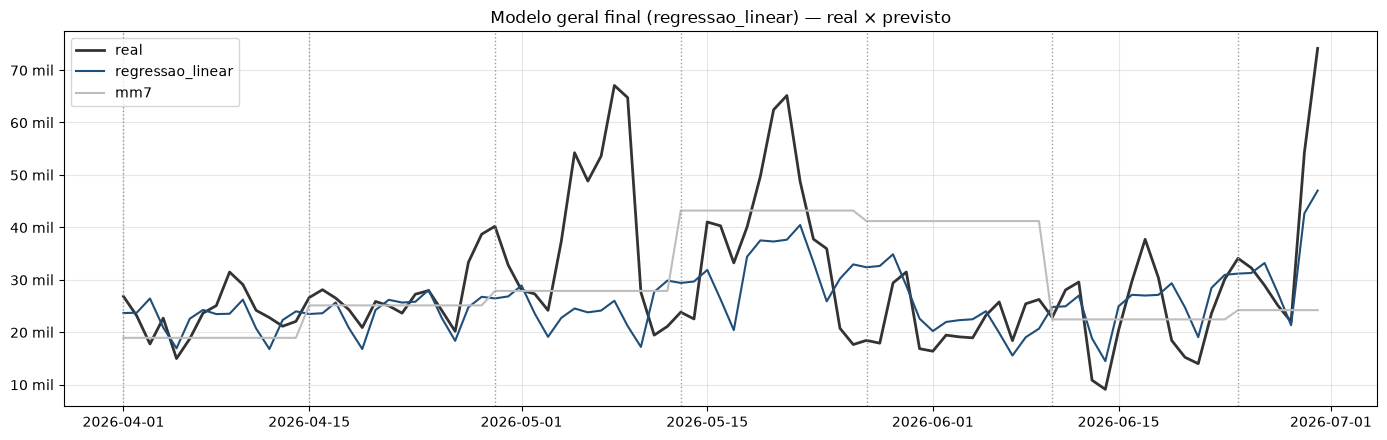

In [14]:
from gb_ml.features import COLUNAS_EVENTO

final = tabela_comparacao([*FABRICAS, "vencedor_ajustado", MELHOR_BASELINE])
final = final.rename(index={"vencedor_ajustado": f"{VENCEDOR} (ajustado)"})
display(final)

INEDITOS = dias_ineditos(df, folds_teste, COLUNAS_EVENTO)
complementares = pd.DataFrame({
    f"geral — {VENCEDOR} (modelo final)": metricas_complementares(previsoes[MODELO_FINAL], INEDITOS),
    MELHOR_BASELINE: metricas_complementares(previsoes[MELHOR_BASELINE], INEDITOS),
}).T
display(formatar_pct(complementares))
plot_real_previsto([MODELO_FINAL, MELHOR_BASELINE], f"Modelo geral final ({VENCEDOR}) — real × previsto")

### Diagnóstico

- **Modelo geral final:** regressão linear, com WAPE do total do dia de **26,1%** contra 35,8% do mm7 (skill de 27%).
- **Viés de −12%:** o modelo subestima e **fica fora do quality gate**, sobretudo pelo Dia das Mães, que era inédito no teste.
- **Fora dos eventos inéditos, o WAPE cai para 20,2%.** No **total da semana**, fica em **19,1%** (mm7: 30,3%).

# 10. SHAP — impacto de cada feature

Impacto médio absoluto de cada feature nos três modelos (treinados com toda a base e parâmetros da etapa 1; o vencedor com os parâmetros finais), como participação % do total. Para a regressão linear, o SHAP é coeficiente × (valor − média).

/tmp/claude-0/-home-user-Projeto-GB---ML/bc10f0c5-3b36-55ae-bce6-001d2a05bc90/scratchpad/venvbq/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


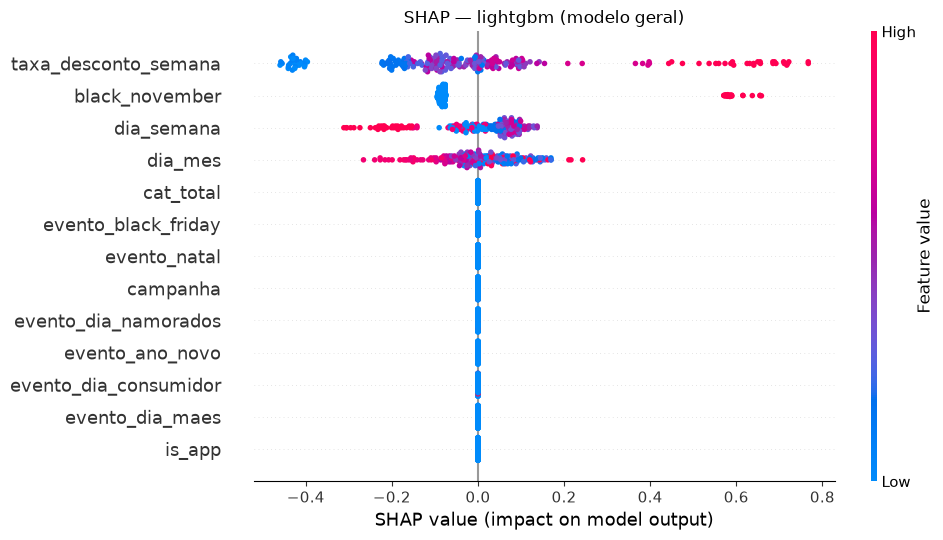

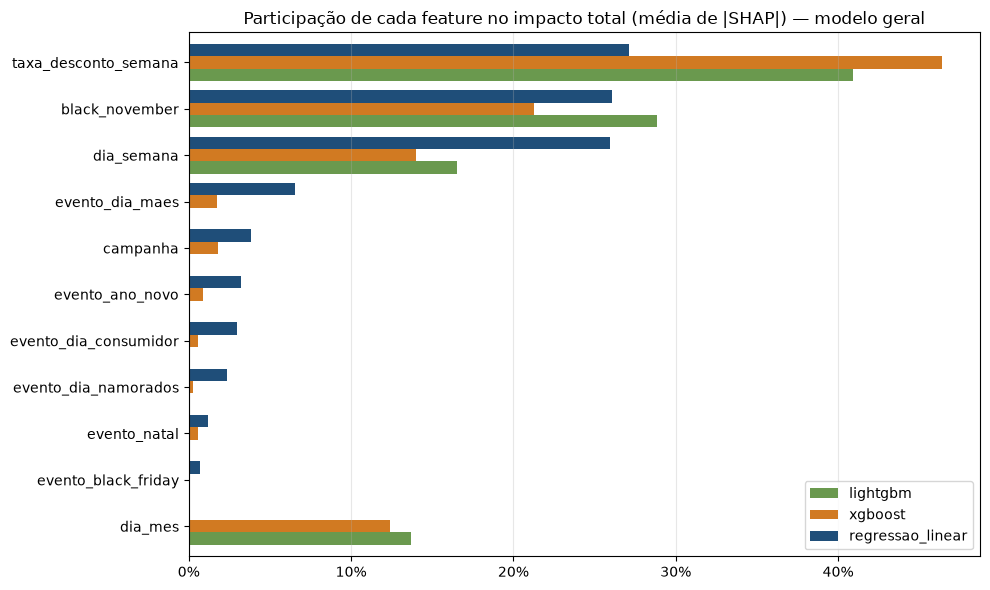

In [15]:
import shap

from gb_ml.features import matriz_linear

parametros_shap = {nome: (PARAMETROS_FINAIS if nome == VENCEDOR else PADRAO[nome]) for nome in FABRICAS}
importancia = {}
for nome in ["lightgbm", "xgboost"]:
    modelo, X, _ = treinar_arvore(nome, parametros_shap[nome])
    valores = shap.TreeExplainer(modelo).shap_values(X)
    importancia[nome] = pd.Series(np.abs(valores).mean(axis=0), index=X.columns)
    if nome == "lightgbm":
        plt.figure()
        shap.summary_plot(valores, X, max_display=15, show=False, plot_size=(10, 5.5))
        plt.title("SHAP — lightgbm (modelo geral)")
        plt.tight_layout()
        plt.show()

modelo_shap = ajustar_linear(df, **parametros_shap["regressao_linear"])
X_lin = matriz_linear(df, usar_lags=parametros_shap["regressao_linear"]["usar_lags"])[modelo_shap.params.index.drop("const")].dropna()
importancia["regressao_linear"] = ((X_lin - X_lin.mean()) * modelo_shap.params.drop("const")).abs().mean()


def agrupar(nome_coluna: str) -> str:
    if nome_coluna.startswith("dia_semana"):
        return "dia_semana"
    if nome_coluna.startswith(("lag_", "mm")):
        return "lags (histórico)"
    return nome_coluna


importancia = pd.DataFrame({m: (s.groupby(s.index.map(agrupar)).sum() / s.sum()) for m, s in importancia.items()}).fillna(0)
importancia = importancia.loc[lambda d: d.max(axis=1) > 0.001].sort_values(VENCEDOR)
ax = importancia.plot.barh(figsize=(10, 6), color=[CORES_MODELO[m] for m in importancia.columns], width=0.8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Participação de cada feature no impacto total (média de |SHAP|) — modelo geral")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Diagnóstico

- **Desconto, Black November e dia da semana** explicam cerca de 80% do impacto nos três modelos.
- **As árvores apoiam muito mais no desconto** (41–46%) do que a regressão (27%). Também usam o `dia_mes`, que tem pouco sentido de negócio, como atalho para separar dias de novembro. É mais um sinal de que, com 242 linhas, as árvores memorizam em vez de generalizar.
- **Na regressão, os eventos aparecem com peso próprio** (Dia das Mães 7%, campanha 4%).

# 11. Sensibilidade à premissa do desconto

Mesmo teste do notebook por categoria, para o modelo final:
- **mensal:** nos dias previstos, a taxa da semana é trocada pela média do mês;
- **sem desconto:** o modelo é treinado e testado sem a informação de desconto.

In [16]:
mes = df["data"].dt.to_period("M")
grupo = df.groupby(mes)
taxa_mensal = grupo["vlr_venda_desconto"].transform("sum") / (
    grupo["receita_aprovada"].transform("sum") + grupo["vlr_venda_desconto"].transform("sum")
)


def com_taxa(ajustar_prever, taxa):
    def ajustar_prever_cenario(treino, teste):
        return ajustar_prever(treino, teste.assign(**{COLUNA_DESCONTO_GERAL: taxa.loc[teste.index]}))
    return ajustar_prever_cenario


fabrica_final = FABRICAS[VENCEDOR](**PARAMETROS_FINAIS)
sensibilidade = pd.Series({
    "premissa (semanal do total)": resumo_backtest(previsoes[MODELO_FINAL])["wape_dia"],
    "mensal": resumo_backtest(rodar_backtest(df, folds_teste, com_taxa(fabrica_final, taxa_mensal)))["wape_dia"],
    "sem desconto": resumo_backtest(rodar_backtest(df.assign(**{COLUNA_DESCONTO_GERAL: 0.0}), folds_teste, fabrica_final))["wape_dia"],
    f"{MELHOR_BASELINE} (baseline)": WAPE_BASELINE,
}, name=f"WAPE do total do dia — {VENCEDOR}")
display(sensibilidade.map(lambda v: f"{v:.1%}").to_frame())

,WAPE do total do dia — regressao_linear
premissa (semanal do total),26.1%
mensal,28.9%
sem desconto,29.6%
mm7 (baseline),35.8%


### Diagnóstico

- **Plano mensal:** o WAPE sobe de 26,1% para 28,9%.
- **Sem desconto:** sobe para 29,6%.
- **No modelo geral, o desconto vale menos** (3,5 p.p.) do que no modelo por categoria (7,6 p.p.). Sem a abertura por categoria, a taxa da semana perde a variação entre categorias, que era o que mais explicava o volume de cada série.

# 12. Geral × categoria: compensa?

Recalculamos aqui o modelo vencedor do `modelo_machine_learning.ipynb` (**LightGBM por canal × categoria, parâmetros padrão, objetivo Poisson, sem lags**) nas mesmas rodadas, e somamos as previsões das 18 séries no total do dia. Os dois respondem à mesma pergunta (quanto vamos vender no dia), então a comparação é direta.

,wape_dia,vies_dia,wape_dia_sem_ineditos,wape_semana
geral (diário),26.1%,-12.0%,20.2%,19.1%
categoria (diário),25.5%,-7.4%,21.8%,18.5%
mm7,35.8%,-0.3%,36.1%,30.3%


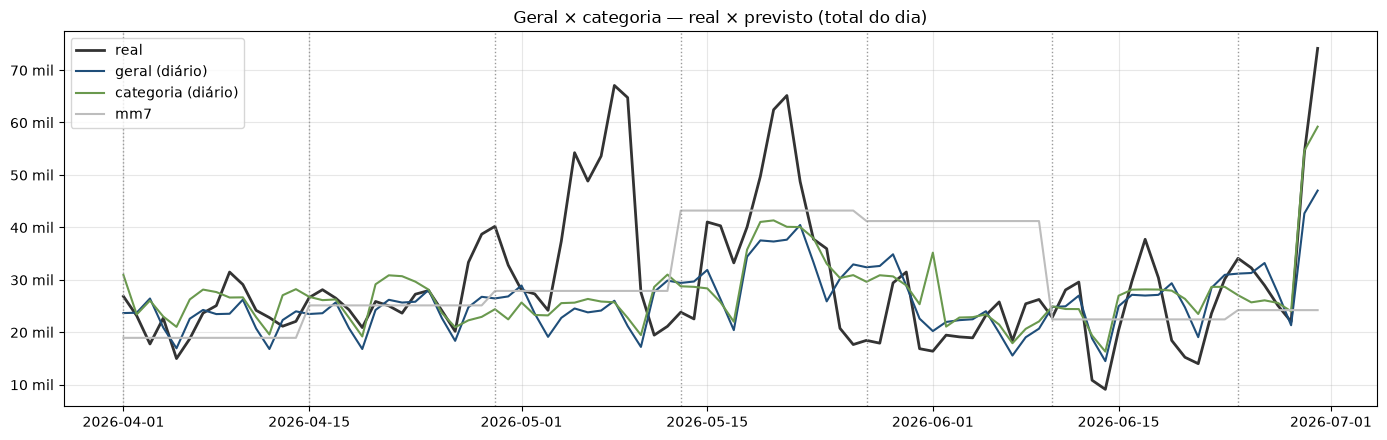

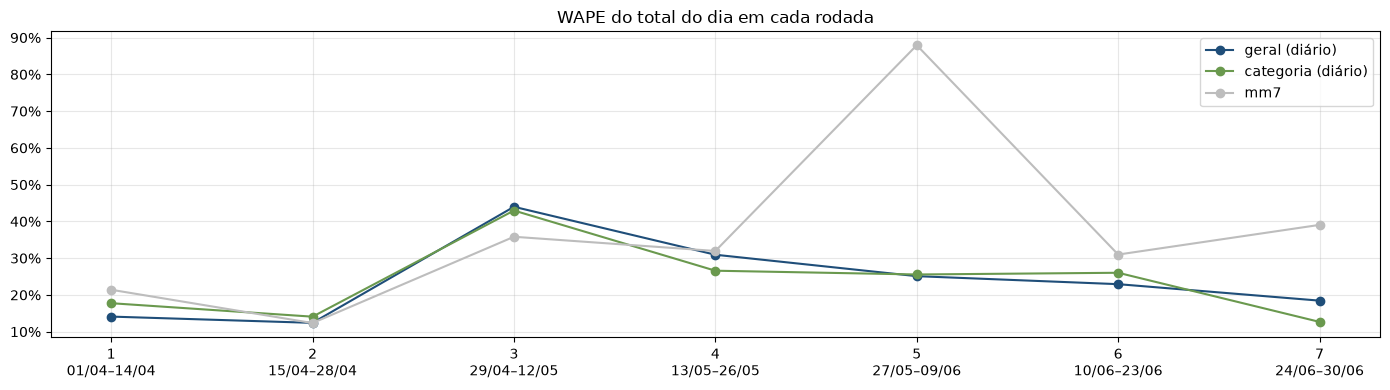

,geral (diário),categoria (diário),mm7
rodada,,,
1,14.1%,17.7%,21.4%
2,12.4%,14.1%,12.3%
3,44.0%,43.0%,35.8%
4,30.9%,26.6%,32.0%
5,25.1%,25.6%,87.9%
6,22.9%,26.0%,31.0%
7,18.4%,12.7%,39.1%


Menor WAPE do total do dia: categoria (diário) (geral − categoria = +0.6 p.p.)


In [17]:
from gb_ml.features import montar_features as montar_features_categoria

df_categoria = montar_features_categoria(base_categoria)
comparacao = {
    "geral (diário)": previsoes[MODELO_FINAL],
    "categoria (diário)": rodar_backtest(df_categoria, folds_teste, lightgbm(alvo="poisson", usar_lags=False)),
    MELHOR_BASELINE: previsoes[MELHOR_BASELINE],
}
resposta = pd.DataFrame({nome: metricas_complementares(p, INEDITOS) for nome, p in comparacao.items()}).T
display(formatar_pct(resposta))

plot_real_previsto(list(comparacao), "Geral × categoria — real × previsto (total do dia)", fonte=comparacao)
display(formatar_pct(plot_erro_rodada(list(comparacao), "WAPE do total do dia em cada rodada", fonte=comparacao)))

melhor = resposta["wape_dia"].drop(MELHOR_BASELINE).idxmin()
diferenca = resposta.loc["geral (diário)", "wape_dia"] - resposta.loc["categoria (diário)", "wape_dia"]
print(f"Menor WAPE do total do dia: {melhor} "
      f"(geral − categoria = {100 * diferenca:+.1f} p.p.)")

### Resposta

**Não compensa trocar o modelo por categoria pelo geral.**

| | Geral (diário) | Categoria (diário) |
|---|---|---|
| WAPE do total do dia | 26,1% | **25,5%** |
| Viés | −12,0% (fora do gate) | **−7,4%** (passa) |
| WAPE sem eventos inéditos | **20,2%** | 21,8% |
| WAPE do total da semana | 19,1% | **18,5%** |

- **A diferença no total do dia é pequena** (0,6 p.p. a favor do modelo por categoria), e as métricas se dividem: o geral erra um pouco menos nos dias comuns, e o por categoria erra menos na semana e tem viés menor.
- **O modelo por categoria passa no quality gate e o geral não** (viés de −12%).
- **O modelo por categoria entrega mais:** a previsão por canal e categoria, que o negócio usa para estoque e campanhas. O geral só dá o total; para abrir por categoria, seria preciso repartir por proporções históricas, o que aumenta o erro por série (ver o teste de previsão hierárquica).
- **Lags:** no total, ajudam as árvores (LightGBM de 40,7% para 27,4%), mas não o suficiente para passar a regressão sem lags. Na regressão, pioram.
- **Uso possível do geral:** como **segunda opinião** para o total. Os dois erram em dias diferentes (o geral foi melhor nas rodadas 1, 2 e 6), então a média dos dois totais tende a ser um pouco mais estável.

# 13. Conclusões

- **O modelo por categoria (LightGBM) continua sendo o recomendado.** Tem praticamente o mesmo erro no total do dia, menor viés, passa no gate e entrega a abertura por canal e categoria.
- **No total, a regressão linear é o melhor modelo** (26,1%), e as árvores falham por falta de dados (242 linhas) e por não extrapolarem picos de desconto.
- **Os lags só ajudam as árvores no total,** e mesmo assim não o bastante.
- **O geral é útil como referência de sanidade do total:** se os dois divergirem muito numa semana, vale investigar a premissa de desconto ou um evento novo.